<a href="https://colab.research.google.com/github/jnanikatadi67-jpg/Dissertation/blob/main/Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ucimlrepo

In [2]:
# IMPORT LIBRARIES AND SUPPRESS WARNINGS

# Basic Libraries
import numpy as np                  # Numerical operations
import pandas as pd                 # Data manipulation and analysis

# Visualization Libraries
import matplotlib.pyplot as plt     # Plotting graphs
import seaborn as sns               # Advanced visualization

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer

# XGBoost Model
from xgboost import XGBClassifier

# Explainability (SHAP)
import shap

# LLM (Hugging Face Transformers)
from transformers import T5Tokenizer, T5ForConditionalGeneration

# Utility Libraries
import warnings                    # To handle warnings
warnings.filterwarnings('ignore') # Suppress all warnings for cleaner output

# Set Visualization Style
sns.set(style="whitegrid")

# Print confirmation
print("All libraries imported successfully. Environment is ready.")

All libraries imported successfully. Environment is ready.


In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
phiusiil_phishing_url_website = fetch_ucirepo(id=967)

# data (as pandas dataframes)
X = phiusiil_phishing_url_website.data.features
y = phiusiil_phishing_url_website.data.targets

# metadata
print(phiusiil_phishing_url_website.metadata)

# variable information
print(phiusiil_phishing_url_website.variables)

{'uci_id': 967, 'name': 'PhiUSIIL Phishing URL (Website)', 'repository_url': 'https://archive.ics.uci.edu/dataset/967/phiusiil+phishing+url+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/967/data.csv', 'abstract': 'PhiUSIIL Phishing URL Dataset is a substantial dataset comprising 134,850 legitimate and 100,945 phishing URLs. Most of the URLs we analyzed, while constructing the dataset, are the latest URLs. Features are extracted from the source code of the webpage and URL. Features such as CharContinuationRate, URLTitleMatchScore, URLCharProb, and TLDLegitimateProb are derived from existing features.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 235795, 'num_features': 54, 'feature_types': ['Real', 'Categorical', 'Integer'], 'demographics': [], 'target_col': ['label'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2024, 'last_updated': 'Sun May 12 

In [4]:
# DATASET INSPECTION AND BASIC PREPARATION

# Combine Features and Target
# Merge X and y into a single DataFrame for easier processing
df = pd.concat([X, y], axis=1)

# Display Basic Information
print("Dataset Shape:", df.shape)          # Number of rows and columns
print("\nFirst 5 Rows:")
display(df.head())                        # Preview dataset

# Check Data Types
print("\nData Types:")
print(df.dtypes)

# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Check Class Distribution
print("\nClass Distribution:")
print(df['label'].value_counts(normalize=True))

# Drop Irrelevant Columns
# 'FILENAME' is explicitly stated as non-informative
if 'FILENAME' in df.columns:
    df = df.drop(columns=['FILENAME'])

# Drop Raw URL/Text Columns (Non-numeric)
# These are not used directly in ML models
non_numeric_cols = ['URL', 'Domain', 'TLD', 'Title']

df = df.drop(columns=[col for col in non_numeric_cols if col in df.columns])

# Confirm Cleaned Dataset
print("\nShape After Dropping Irrelevant Columns:", df.shape)

# Separate Features and Target Again
X = df.drop(columns=['label'])   # Features
y = df['label']                  # Target

print("\nFinal Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Dataset Shape: (235795, 55)

First 5 Rows:


,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1



Data Types:
URL                            object
URLLength                       int64
Domain                         object
DomainLength                    int64
IsDomainIP                      int64
TLD                            object
URLSimilarityIndex            float64
CharContinuationRate          float64
TLDLegitimateProb             float64
URLCharProb                   float64
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCharsInURL      int64
SpacialCharRatioInURL         float64
IsHTTPS                         int64
LineOfCode                      int64

In [5]:
# Drop leakage-prone features
leakage_features = [
    'URLSimilarityIndex',
    'TLDLegitimateProb',
    'URLCharProb',
    'HasSocialNet',
    'HasCopyrightInfo',
    'HasDescription',
    'HasSubmitButton',
    'IsResponsive',
    'DomainTitleMatchScore',
    'URLTitleMatchScore'
]

X = X.drop(columns=[col for col in leakage_features if col in X.columns])

In [6]:
# DATA PREPROCESSING AND FEATURE ENGINEERING

# Copy dataset to avoid modifying original
X_processed = X.copy()

# Log Transformation (for skewed positive features)
# Apply log1p to strictly positive numerical features
# This helps reduce skewness and stabilise variance

positive_cols = X_processed.select_dtypes(include=[np.number]).columns

for col in positive_cols:
    if (X_processed[col] > 0).all():  # strictly positive
        X_processed[col] = np.log1p(X_processed[col])

print("Log transformation applied to strictly positive features.")

# Correlation Analysis (Remove Highly Correlated Features)
# Threshold = 0.95 as per methodology

corr_matrix = X_processed.corr().abs()

# Select upper triangle
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find features to drop
high_corr_features = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.95)]

print(f"Number of highly correlated features to drop: {len(high_corr_features)}")

# Drop correlated features
X_processed = X_processed.drop(columns=high_corr_features)

print("Shape after correlation filtering:", X_processed.shape)

# Feature Scaling (Standardisation)
# StandardScaler ensures zero mean and unit variance

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_processed)

# Convert back to DataFrame for interpretability
X_scaled = pd.DataFrame(X_scaled, columns=X_processed.columns)

print("Feature scaling completed.")

# Train-Test Split (Stratified)
# Maintain class distribution

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTrain-Test Split Completed:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))

Log transformation applied to strictly positive features.
Number of highly correlated features to drop: 0
Shape after correlation filtering: (235795, 40)
Feature scaling completed.

Train-Test Split Completed:
X_train shape: (188636, 40)
X_test shape: (47159, 40)
y_train distribution:
 label
1    0.571895
0    0.428105
Name: proportion, dtype: float64
y_test distribution:
 label
1    0.571895
0    0.428105
Name: proportion, dtype: float64


In [7]:
# CLASS IMBALANCE HANDLING USING RANDOM UNDERSAMPLING

from imblearn.under_sampling import RandomUnderSampler

# Apply Undersampling ONLY on training data
undersampler = RandomUnderSampler(
    sampling_strategy='auto',  # makes classes equal
    random_state=42
)

X_train_under, y_train_under = undersampler.fit_resample(X_train, y_train)

# Check class distribution
print("Before Undersampling:")
print(y_train.value_counts())

print("\nAfter Undersampling:")
print(pd.Series(y_train_under).value_counts())

# Replace training data
X_train = X_train_under
y_train = y_train_under

print("\nUndersampling applied successfully.")
print("New X_train shape:", X_train.shape)

Before Undersampling:
label
1    107880
0     80756
Name: count, dtype: int64

After Undersampling:
label
0    80756
1    80756
Name: count, dtype: int64

Undersampling applied successfully.
New X_train shape: (161512, 40)


In [8]:
# Top features based on correlation with target
top_features = df.corr()['label'].abs().sort_values(ascending=False).head(10)
print(top_features)

label                    1.000000
URLSimilarityIndex       0.860358
HasSocialNet             0.784255
HasCopyrightInfo         0.743358
HasDescription           0.690232
IsHTTPS                  0.609132
DomainTitleMatchScore    0.584905
HasSubmitButton          0.578561
IsResponsive             0.548608
URLTitleMatchScore       0.539419
Name: label, dtype: float64


In [9]:
# Check if any single feature predicts perfectly
for col in X.columns:
    corr = abs(np.corrcoef(X[col], y)[0,1])
    if corr > 0.95:
        print(f"High leakage feature detected: {col} -> {corr}")

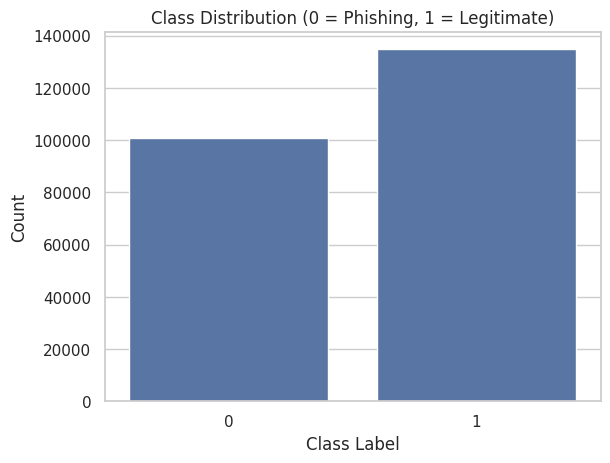

Top Features Used for EDA:
 ['URLSimilarityIndex', 'HasSocialNet', 'HasCopyrightInfo', 'HasDescription', 'IsHTTPS', 'DomainTitleMatchScore', 'HasSubmitButton', 'IsResponsive', 'URLTitleMatchScore']


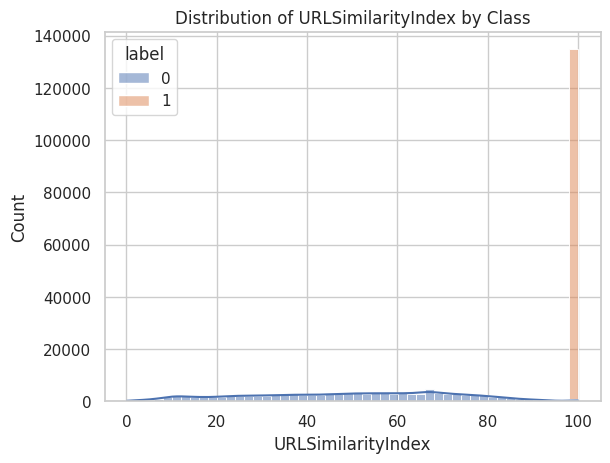

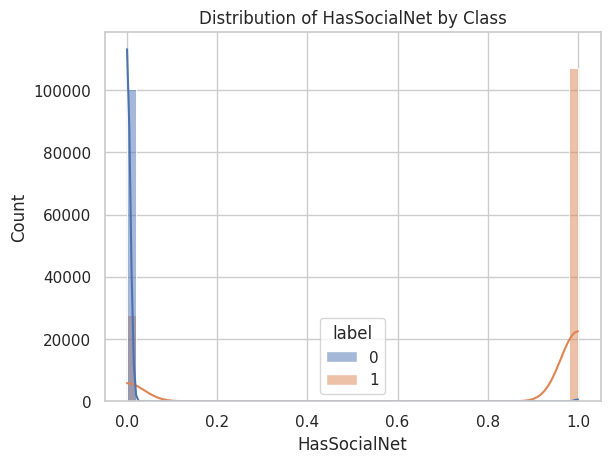

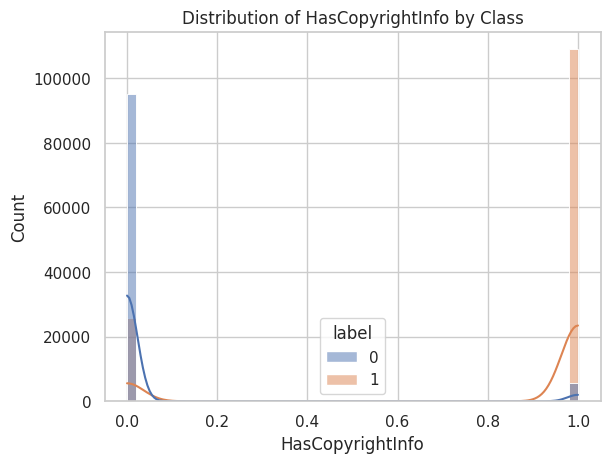

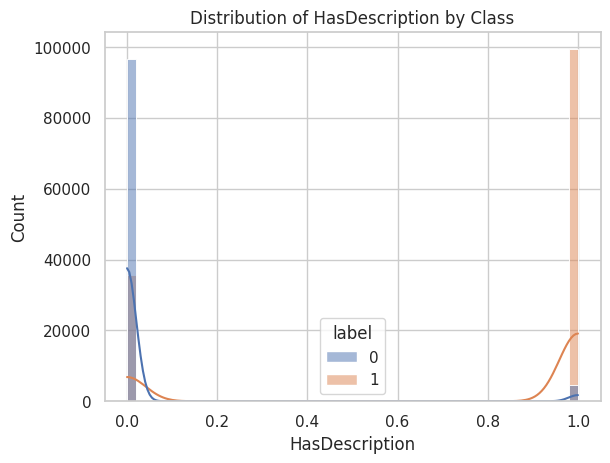

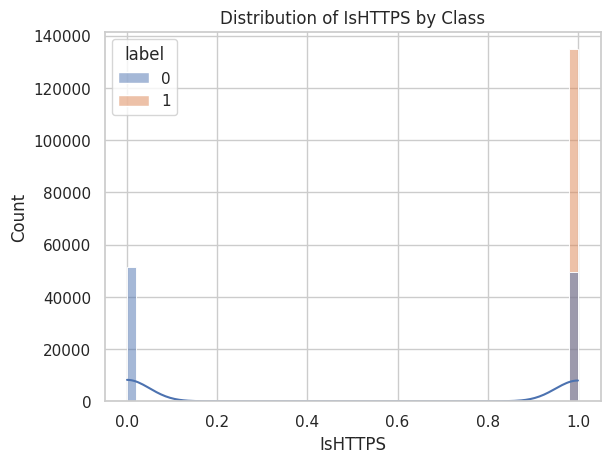

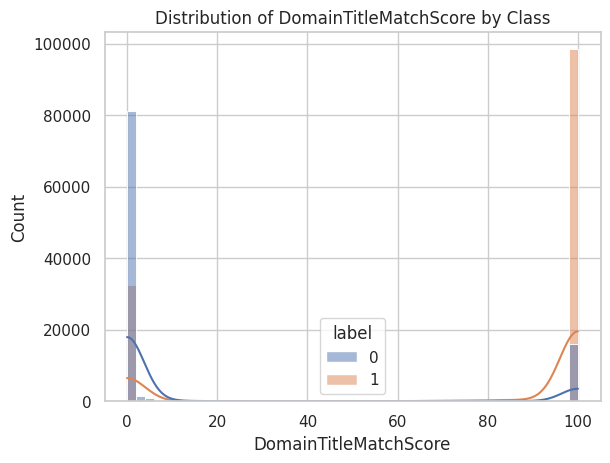

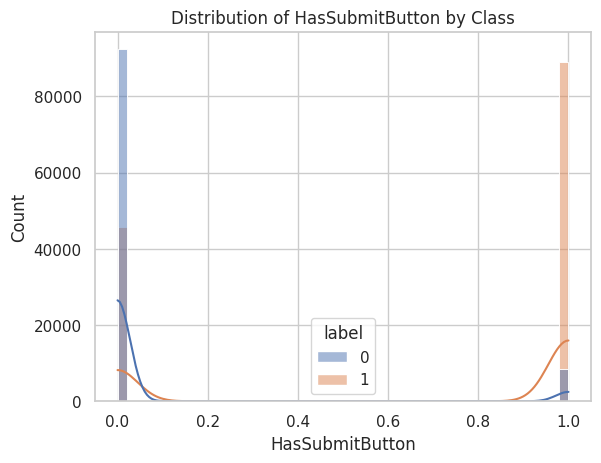

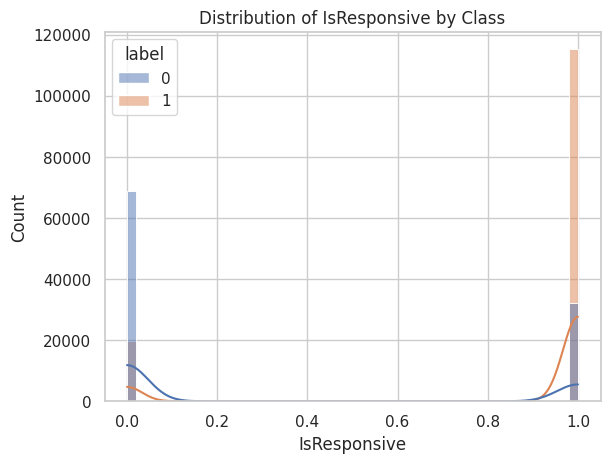

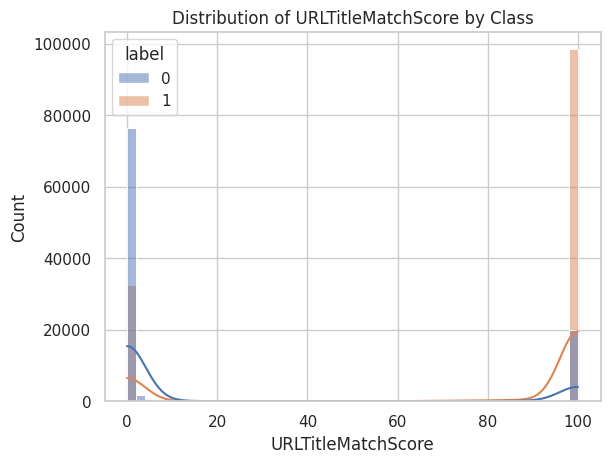

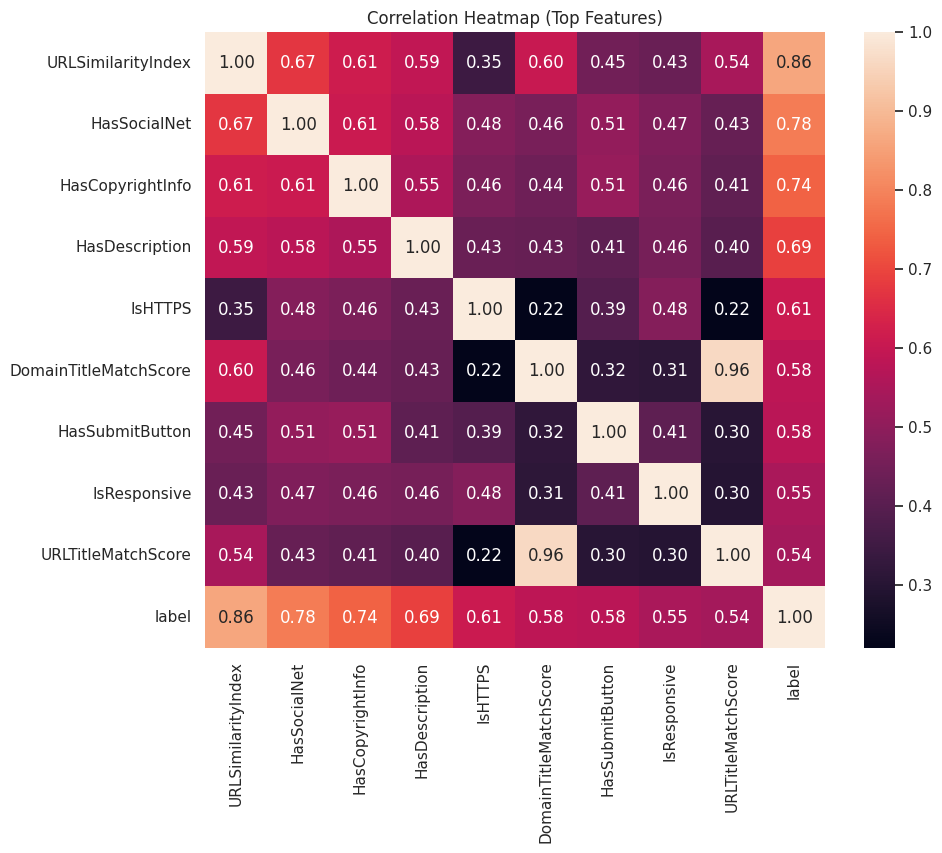

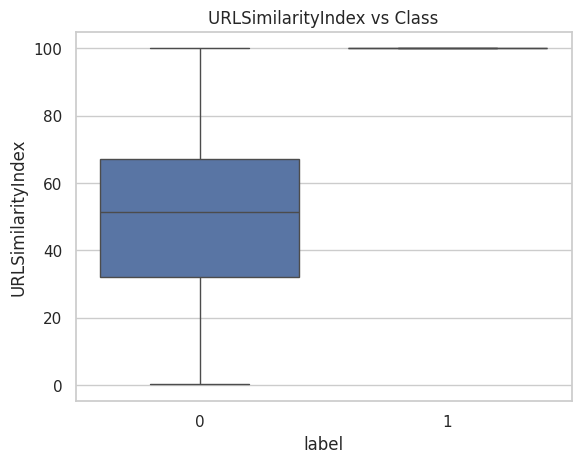

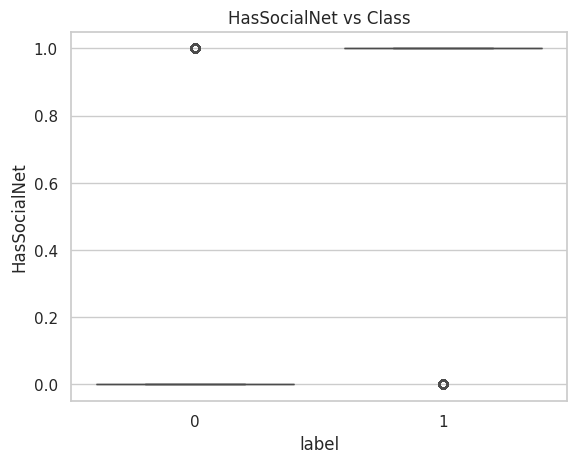

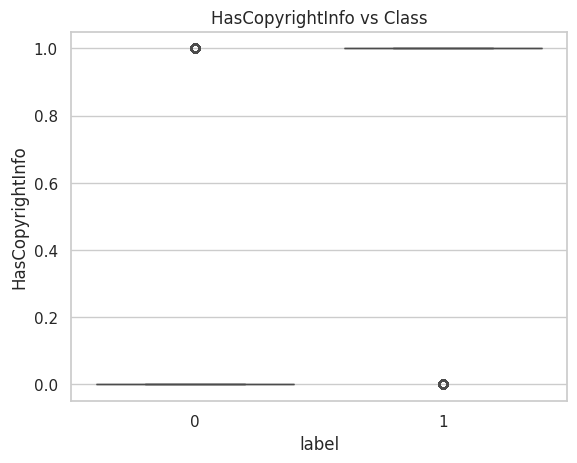

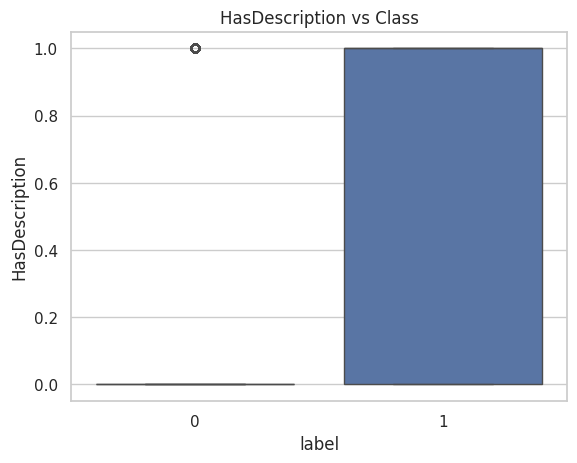

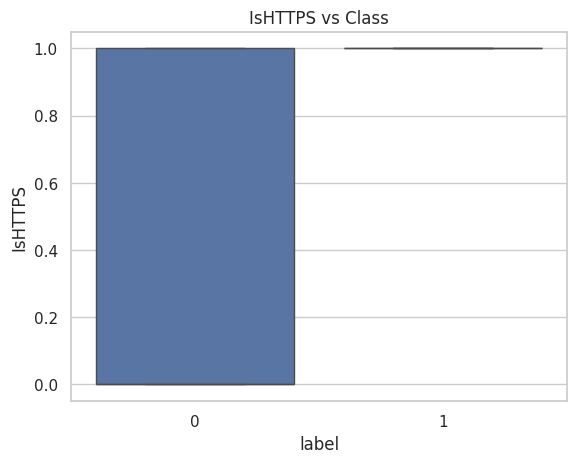

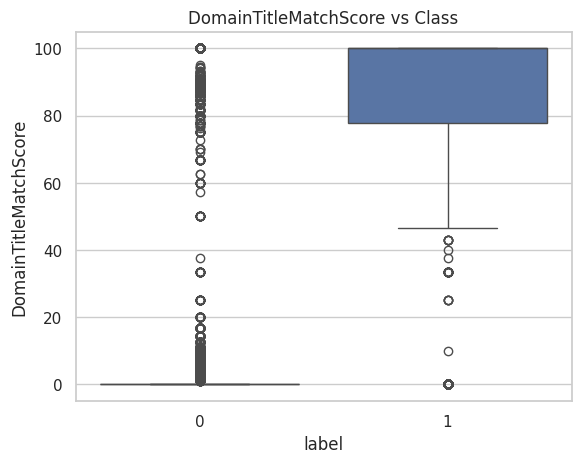

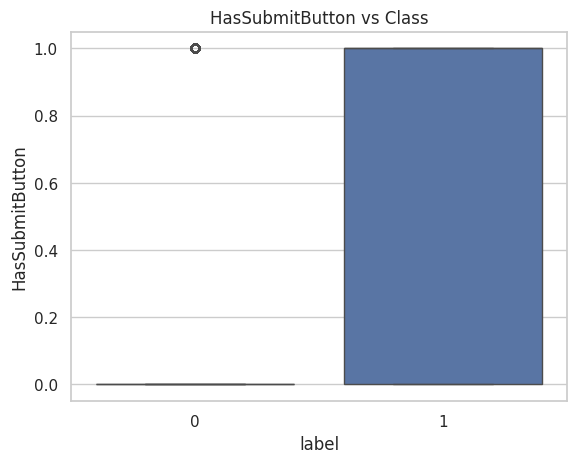

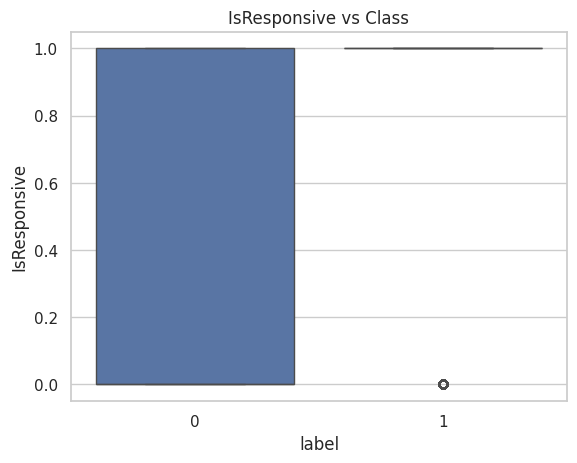

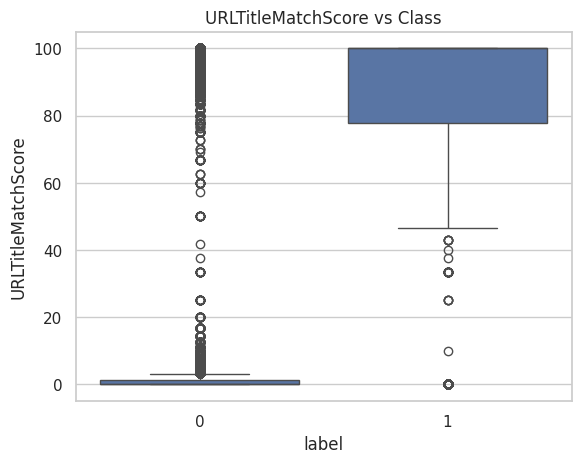

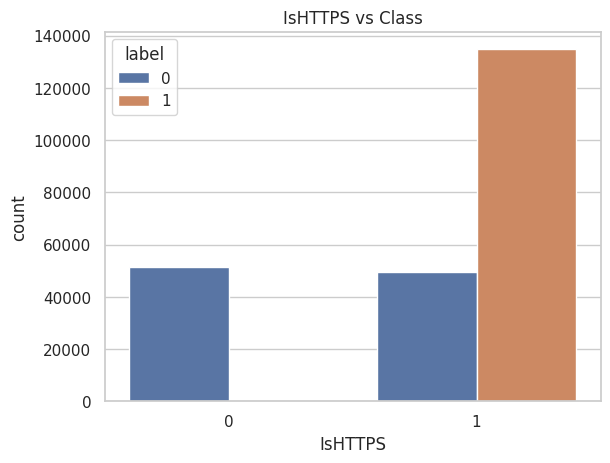

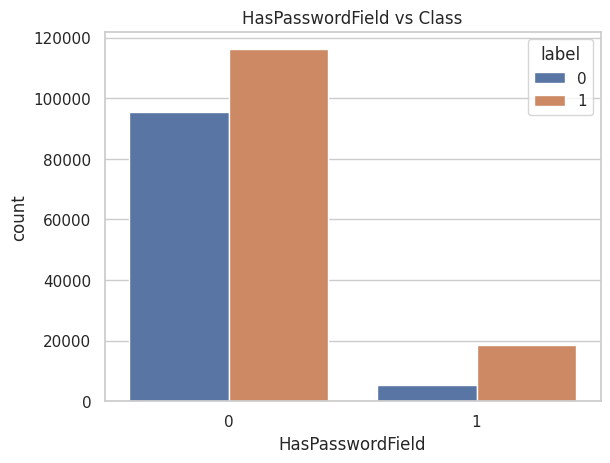

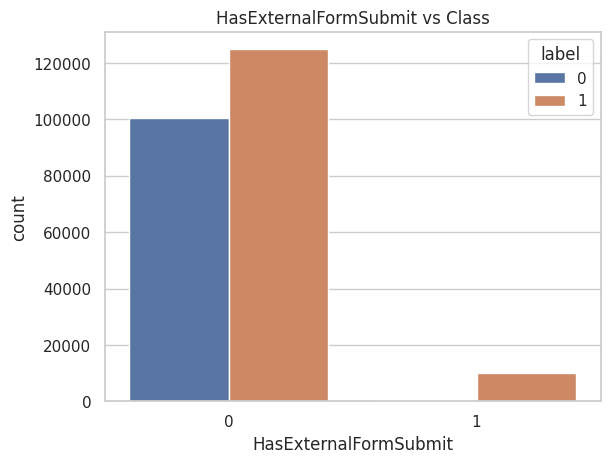

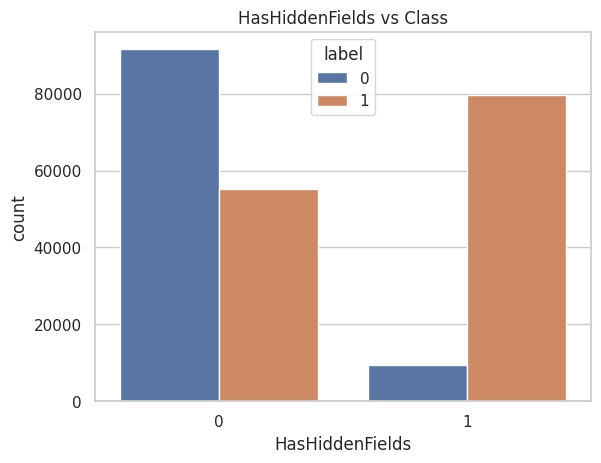

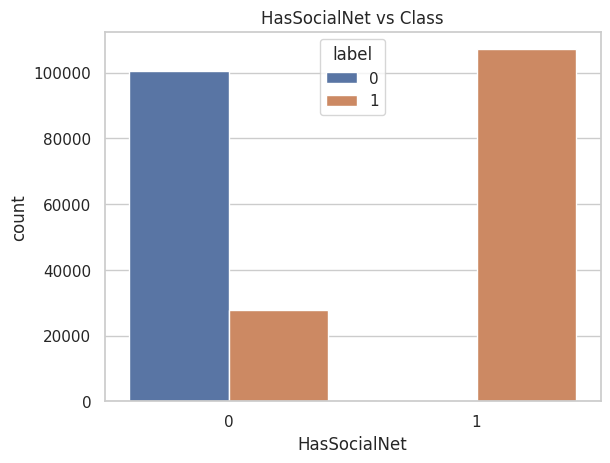

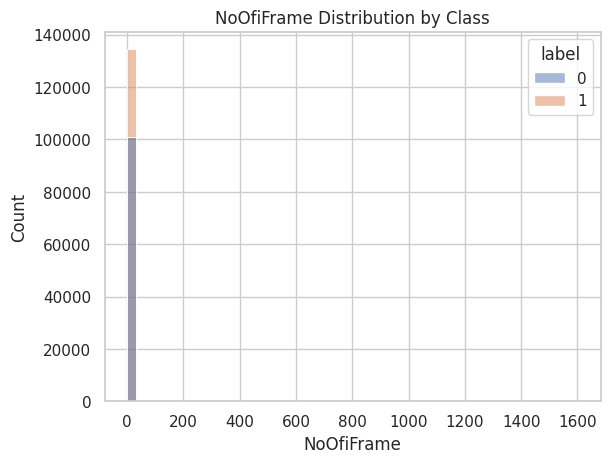

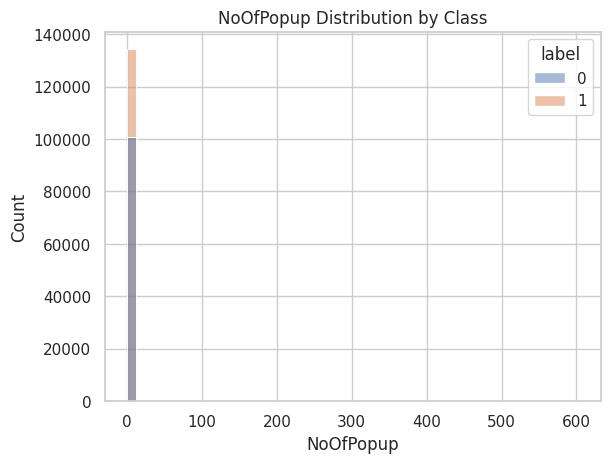

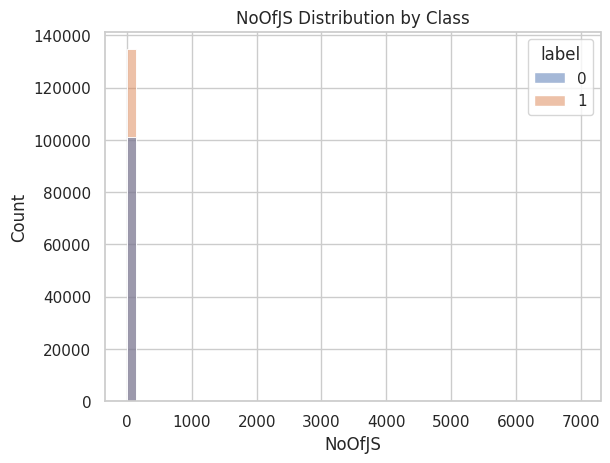

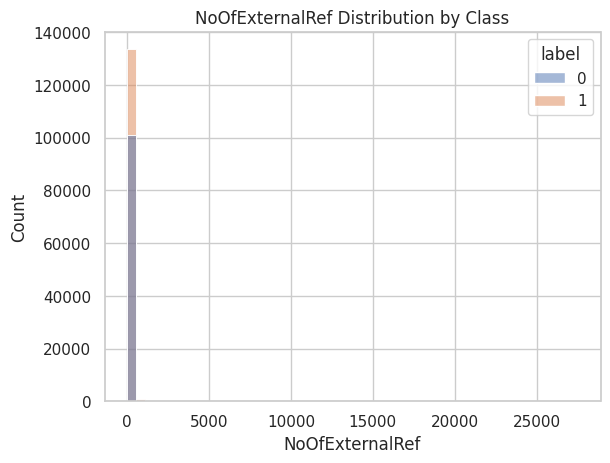

EDA completed successfully.


In [10]:
# EXPLORATORY DATA ANALYSIS (EDA)

# 1. Class Distribution
plt.figure()
sns.countplot(x='label', data=df)
plt.title("Class Distribution (0 = Phishing, 1 = Legitimate)")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.show()


# 2. Top Correlated Features (Data-Driven Selection)
# Use correlation with target (already computed)

top_features = df.corr()['label'].abs().sort_values(ascending=False).head(10).index.tolist()

# Remove label itself
top_features.remove('label')

print("Top Features Used for EDA:\n", top_features)


# 3. Feature Distributions (Top Features)
for feature in top_features:
    plt.figure()
    sns.histplot(data=df, x=feature, hue='label', bins=50, kde=True)
    plt.title(f"Distribution of {feature} by Class")
    plt.show()


# 4. Correlation Heatmap (Top Features)
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features + ['label']].corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Top Features)")
plt.show()


# 5. Boxplots (Outlier + Class Separation)
for feature in top_features:
    plt.figure()
    sns.boxplot(x='label', y=feature, data=df)
    plt.title(f"{feature} vs Class")
    plt.show()


# 6. Binary Feature Analysis (High-Impact Only)
binary_features = [
    'IsHTTPS',
    'HasPasswordField',
    'HasExternalFormSubmit',
    'HasHiddenFields',
    'HasSocialNet'
]

for feature in binary_features:
    if feature in df.columns:
        plt.figure()
        sns.countplot(x=feature, hue='label', data=df)
        plt.title(f"{feature} vs Class")
        plt.show()


# 7. Behavioural Features (Webpage Indicators)
advanced_features = [
    'NoOfiFrame',
    'NoOfPopup',
    'NoOfJS',
    'NoOfExternalRef'
]

for feature in advanced_features:
    if feature in df.columns:
        plt.figure()
        sns.histplot(data=df, x=feature, hue='label', bins=50)
        plt.title(f"{feature} Distribution by Class")
        plt.show()


print("EDA completed successfully.")

Logistic Regression training completed.
XGBoost training completed.

===== Logistic Regression Evaluation =====
Accuracy:  0.9997
Precision: 0.9996
Recall:    0.9999
F1-Score:  0.9997
ROC-AUC:   1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



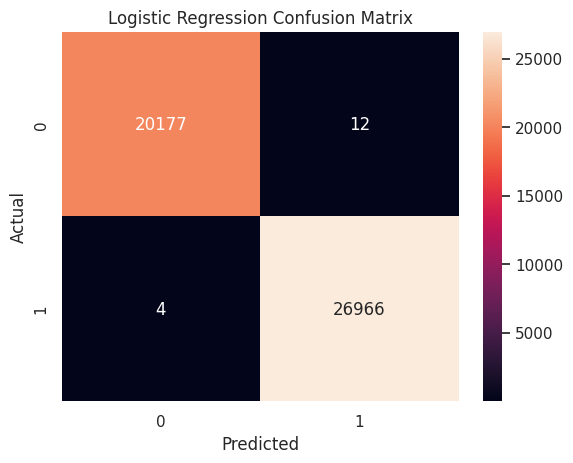


===== XGBoost Evaluation =====
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



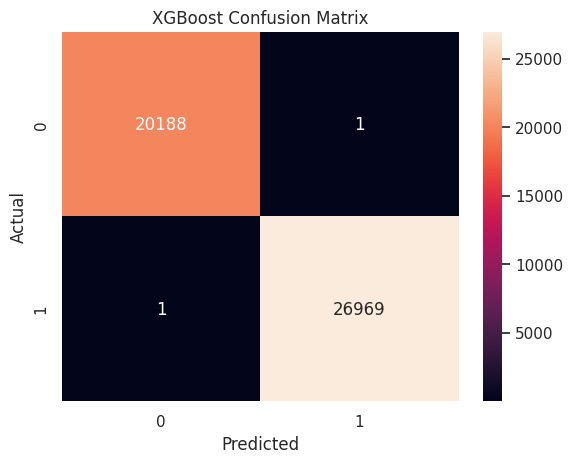

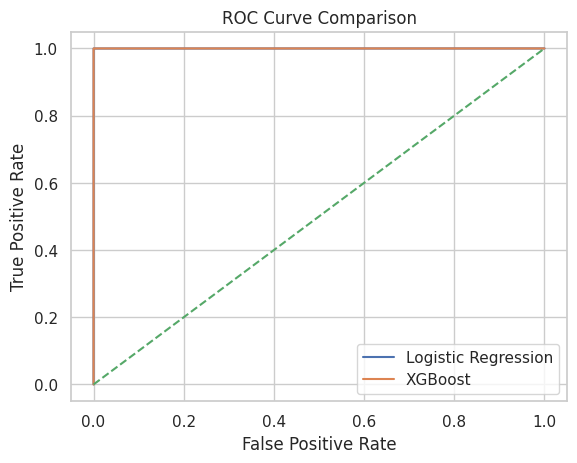

In [11]:
# MODEL TRAINING AND EVALUATION

# Logistic Regression Model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression training completed.")


# XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost training completed.")


# Evaluation Function
def evaluate_model(y_true, y_pred, y_prob, model_name):

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_prob)

    print(f"\n===== {model_name} Evaluation =====")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# Evaluate Models
evaluate_model(y_test, y_pred_lr, y_prob_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_xgb, y_prob_xgb, "XGBoost")


# ROC Curve Comparison
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

SHAP values computed for XGBoost.


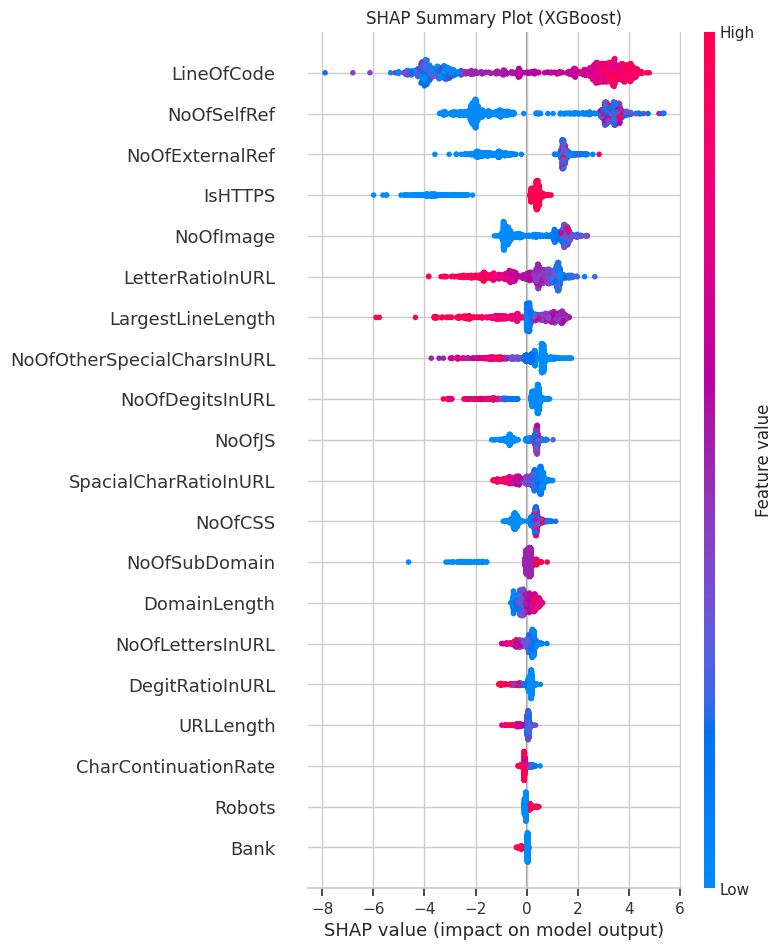

SHAP values computed for Logistic Regression.


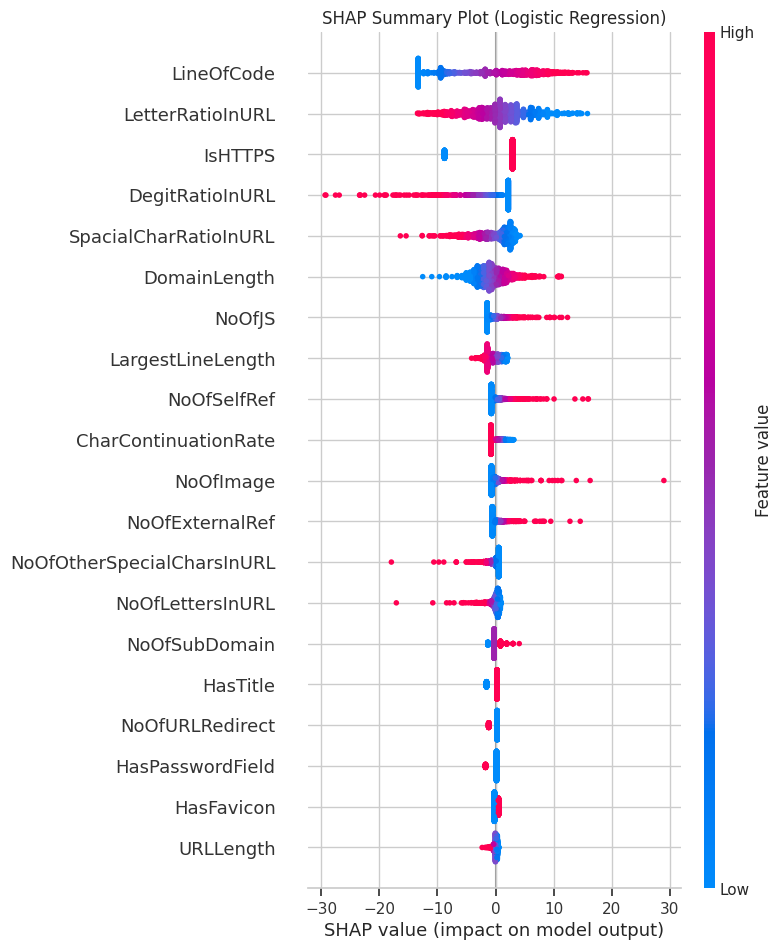

Explaining instance index: 0


In [12]:
# SHAP EXPLAINABILITY

import shap

# SHAP for XGBoost (TreeExplainer)
explainer_xgb = shap.TreeExplainer(xgb_model)

# Compute SHAP values (use a sample for efficiency)
X_sample = X_test.sample(n=1000, random_state=42)

shap_values_xgb = explainer_xgb.shap_values(X_sample)

print("SHAP values computed for XGBoost.")

# Global Feature Importance (XGBoost)
plt.figure()
shap.summary_plot(shap_values_xgb, X_sample, show=False)
plt.title("SHAP Summary Plot (XGBoost)")
plt.show()


# SHAP for Logistic Regression
explainer_lr = shap.LinearExplainer(lr_model, X_train)

shap_values_lr = explainer_lr.shap_values(X_sample)

print("SHAP values computed for Logistic Regression.")


# Global Feature Importance (Logistic Regression)
plt.figure()
shap.summary_plot(shap_values_lr, X_sample, show=False)
plt.title("SHAP Summary Plot (Logistic Regression)")
plt.show()


# Local Explanation (Single Instance)
# Pick one sample
index = 0

print("Explaining instance index:", index)

shap.initjs()

# XGBoost local explanation
shap.force_plot(
    explainer_xgb.expected_value,
    shap_values_xgb[index],
    X_sample.iloc[index]
)

In [13]:
# EXTRACT TOP FEATURES FOR LLM

def get_top_shap_features(shap_values, X_data, index, top_k=5):

    values = shap_values[index]
    feature_names = X_data.columns

    # Create DataFrame
    shap_df = pd.DataFrame({
        'feature': feature_names,
        'shap_value': values
    })

    # Sort by absolute importance
    shap_df['abs_val'] = shap_df['shap_value'].abs()
    shap_df = shap_df.sort_values(by='abs_val', ascending=False)

    return shap_df.head(top_k)


# Example: extract top features for one instance
top_features_instance = get_top_shap_features(
    shap_values_xgb,
    X_sample,
    index=0,
    top_k=5
)

print(top_features_instance)

             feature  shap_value   abs_val
19        LineOfCode    3.653484  3.653484
37       NoOfSelfRef    3.289827  3.289827
34         NoOfImage    1.495375  1.495375
39   NoOfExternalRef    1.381348  1.381348
10  LetterRatioInURL    1.221397  1.221397


In [14]:
import torch
from transformers import T5ForConditionalGeneration, T5Tokenizer
import re

In [15]:
# LLM EXPLANATION — LaMini-Flan-T5-783M (Instruction-Tuned)

from transformers import T5ForConditionalGeneration, T5Tokenizer
import torch
import pandas as pd

# ---- LOAD MODEL ----
MODEL_NAME = "MBZUAI/LaMini-Flan-T5-783M"
print(f"Loading {MODEL_NAME} ...")
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
model_t5  = T5ForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)
model_t5.eval()
device   = "cuda" if torch.cuda.is_available() else "cpu"
model_t5 = model_t5.to(device)
print(f"LaMini-Flan-T5-783M ready on {device}.")

# ---- FEATURE DEFINITIONS ----
FEATURE_DEFINITIONS = {
    "LineOfCode":       "total HTML lines (high = bloated page, common in phishing kits)",
    "NoOfSelfRef":      "self-referencing links (high = traps users in a loop)",
    "NoOfImage":        "images on page (phishing pages clone real site images)",
    "NoOfExternalRef":  "links to external domains (low = isolated fake page)",
    "LetterRatioInURL": "letter ratio in URL (high = obfuscated/auto-generated domain)",
    "URLLength":        "URL length (very long = hiding true destination)",
    "NoOfSubDomain":    "number of subdomains (many = domain spoofing)",
    "HasHTTPS":         "HTTPS present (0 = unencrypted, suspicious)",
    "NoOfJS":           "JavaScript files loaded (high = complex malicious scripts)",
    "NoOfRedirect":     "redirects (high = hiding final malicious destination)",
}

# ---- PROMPT ----
def build_flant5_prompt(prediction: int, top_features: pd.DataFrame) -> str:
    label = "phishing" if prediction == 1 else "legitimate"

    feature_lines = []
    for _, row in top_features.iterrows():
        fname     = row["feature"]
        direction = "suspicious" if row["shap_value"] > 0 else "safe"
        defn      = FEATURE_DEFINITIONS.get(fname, "a URL/page characteristic")
        feature_lines.append(f"- {fname}: {defn} [{direction}]")
    features_block = "\n".join(feature_lines)

    prompt = f"""You are a cybersecurity analyst. A phishing detection model returned the following result. Write a clear 2-sentence explanation for a SOC analyst describing why this URL is {label} and what action to take.

URL verdict: {label}
Key features detected:
{features_block}

Explanation:"""

    return prompt

# ---- GENERATION ----
def get_flant5_explanation(prediction: int, top_features: pd.DataFrame,
                            max_new_tokens: int = 150) -> str:
    prompt = build_flant5_prompt(prediction, top_features)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        max_length=400,
        truncation=True
    ).to(device)

    with torch.no_grad():
        outputs = model_t5.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3,
            repetition_penalty=2.5,
            length_penalty=1.2,
        )

    input_length = inputs["input_ids"].shape[1]
    new_tokens   = outputs[0][input_length:]
    explanation  = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    if len(explanation) < 20:
        explanation = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

    return explanation

# ---- BATCH ----
def explain_predictions_batch(X_sample, shap_values, y_pred, y_prob,
                               urls, top_k=5, max_explain=20):
    results = []
    for i in range(min(max_explain, len(X_sample))):
        top_features = get_top_shap_features(shap_values, X_sample, index=i, top_k=top_k)
        pred         = int(y_pred[i])
        conf         = float(y_prob[i]) if pred == 1 else 1 - float(y_prob[i])
        label        = "Phishing" if pred == 1 else "Legitimate"
        explanation  = get_flant5_explanation(pred, top_features)

        results.append({
            "instance_index": i,
            "url":            urls[i],
            "prediction":     label,
            "confidence":     f"{conf * 100:.1f}%",
            "explanation":    explanation
        })
        print(f"[{i+1}/{min(max_explain, len(X_sample))}] {label} | {explanation[:100]}...")

    return pd.DataFrame(results)

# ---- RUN ----
urls            = [f"sample_url_{i}" for i in range(len(X_sample))]
explanations_df = explain_predictions_batch(
    X_sample    = X_sample,
    shap_values = shap_values_xgb,
    y_pred      = y_pred_xgb,
    y_prob      = y_prob_xgb,
    urls        = urls,
    top_k       = 5,
    max_explain = 5
)

# ---- PREVIEW ----
print("\n===== EXPLANATION PREVIEW =====")
for _, row in explanations_df.iterrows():
    print(f"\n[{row['instance_index']}] {row['prediction']} ({row['confidence']})")
    print(f"  {row['explanation']}")

Loading MBZUAI/LaMini-Flan-T5-783M ...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/860 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/560 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

LaMini-Flan-T5-783M ready on cuda.
[1/5] Phishing | A SOC analyst can take the following action if this URL is suspected to be Phishing: 1. Verify that ...
[2/5] Phishing | A SOC analyst would need to take action against the phishing URL by verifying that there are no self...
[3/5] Phishing | A SOC analyst can take the following action if this URL is suspected to be an example of Phishing: 1...
[4/5] Phishing | A SOC analyst would need to take action against the phishing website by verifying that it is not leg...
[5/5] Phishing | A SOC analyst can take action by verifying if this URL is legitimate or not. If it's found to be fra...

===== EXPLANATION PREVIEW =====

[0] Phishing (100.0%)
  A SOC analyst can take the following action if this URL is suspected to be Phishing: 1. Verify that there are total HTML lines, self-referential links and images on page. 2. Look out for isolated fake pages with high letter ratios such as those found in these types of websites which often contain pseu

In [16]:
# LLM EXPLANATION — FLAN-T5-large

from transformers import T5ForConditionalGeneration, T5Tokenizer
import torch
import pandas as pd

# ---- LOAD FLAN-T5-large ----

MODEL_NAME = "google/flan-t5-large"
print(f"Loading {MODEL_NAME} ...")
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
model_t5  = T5ForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16
)
model_t5.eval()
device   = "cuda" if torch.cuda.is_available() else "cpu"
model_t5 = model_t5.to(device)
print(f"Flan-T5-large ready on {device}.")


# ---- PROMPT ----
# Give concrete definitions so the model does not hallucinate meanings

FEATURE_DEFINITIONS = {
    "LineOfCode":        "the total number of lines of HTML code (high = complex/bloated page, common in phishing kits)",
    "NoOfSelfRef":       "the number of self-referencing links (high = page traps users in a loop)",
    "NoOfImage":         "the number of images on the page (phishing pages often clone images from real sites)",
    "NoOfExternalRef":   "the number of links pointing to external domains (low = isolated fake page)",
    "LetterRatioInURL":  "the ratio of letters to total characters in the URL (high = obfuscated domain)",
    "URLLength":         "the total length of the URL (very long = hiding the true destination)",
    "NoOfSubDomain":     "the number of subdomains (many = domain spoofing technique)",
    "HasHTTPS":          "whether the URL uses HTTPS (0 = no encryption, suspicious)",
    "NoOfJS":            "the number of JavaScript files loaded (high = complex malicious scripts)",
    "NoOfRedirect":      "the number of redirects (high = hiding the final malicious destination)",
}

def build_flant5_prompt(prediction: int, top_features: pd.DataFrame) -> str:
    label = "phishing" if prediction == 1 else "legitimate"

    # Build feature lines with definitions where available
    feature_lines = []
    for _, row in top_features.iterrows():
        fname     = row["feature"]
        direction = "suspicious" if row["shap_value"] > 0 else "safe"
        defn      = FEATURE_DEFINITIONS.get(fname, f"a URL/page characteristic")
        feature_lines.append(f"- {fname}: {defn} — marked as {direction}")

    features_block = "\n".join(feature_lines)

    # Few-shot style: show the model what a good answer looks like
    prompt = f"""You are a cybersecurity expert. Analyse the following phishing detection result and write a clear 2-sentence explanation for a security analyst.

Example:
URL verdict: phishing
Features:
- NoOfSelfRef: the number of self-referencing links — marked as suspicious
- LetterRatioInURL: the ratio of letters in the URL — marked as suspicious
Explanation: This URL shows multiple self-referencing links that trap users in a loop, preventing them from navigating away — a hallmark of credential-harvesting pages. The high letter ratio in the URL suggests an auto-generated domain designed to mimic a trusted brand; the analyst should block this domain immediately and check mail logs for delivery to employees.

Now analyse this:
URL verdict: {label}
Features:
{features_block}
Explanation:"""

    return prompt


def get_flant5_explanation(prediction: int, top_features: pd.DataFrame,
                            max_new_tokens: int = 150) -> str:
    prompt = build_flant5_prompt(prediction, top_features)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        max_length=512,
        truncation=True
    ).to(device)

    with torch.no_grad():
        outputs = model_t5.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3,
            repetition_penalty=2.5,
            length_penalty=1.2,
        )

    # Decode only newly generated tokens
    input_length = inputs["input_ids"].shape[1]
    new_tokens   = outputs[0][input_length:]
    explanation  = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    # Fallback if slice is empty
    if len(explanation) < 20:
        explanation = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

    return explanation


# ---- BATCH

def explain_predictions_batch(X_sample, shap_values, y_pred, y_prob,
                               urls, top_k=5, max_explain=20):
    results = []
    for i in range(min(max_explain, len(X_sample))):
        top_features = get_top_shap_features(shap_values, X_sample, index=i, top_k=top_k)
        pred         = int(y_pred[i])
        conf         = float(y_prob[i]) if pred == 1 else 1 - float(y_prob[i])
        label        = "Phishing" if pred == 1 else "Legitimate"
        explanation  = get_flant5_explanation(pred, top_features)

        results.append({
            "instance_index": i,
            "url":            urls[i],
            "prediction":     label,
            "confidence":     f"{conf * 100:.1f}%",
            "explanation":    explanation
        })
        print(f"[{i+1}/{min(max_explain, len(X_sample))}] {label} | {explanation[:100]}...")

    return pd.DataFrame(results)


# ---- RUN ----
urls            = [f"sample_url_{i}" for i in range(len(X_sample))]
explanations_df = explain_predictions_batch(
    X_sample    = X_sample,
    shap_values = shap_values_xgb,
    y_pred      = y_pred_xgb,
    y_prob      = y_prob_xgb,
    urls        = urls,
    top_k       = 5,
    max_explain = 5
)

# ---- PREVIEW ----
print("\n===== EXPLANATION PREVIEW =====")
for _, row in explanations_df.iterrows():
    print(f"\n[{row['instance_index']}] {row['prediction']} ({row['confidence']})")
    print(f"  {row['explanation']}")

Loading google/flan-t5-large ...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Flan-T5-large ready on cuda.
[1/5] Phishing | If a URL contains multiple self-referential links, it's most likely to be from an isolated fake page...
[2/5] Phishing | This URL shows multiple self-referential links that trap users in a loop. The high LetterRatioInURL ...
[3/5] Phishing | This URL shows multiple self-referential links that trap users in a loop. The high LetterRatioInURL ...
[4/5] Phishing | This URL shows multiple self-referential links that trap users in a loop. The high lineOfCode indica...
[5/5] Phishing | If a page has too many self-referential links, it's most likely to be an isolated fake webpage. The ...

===== EXPLANATION PREVIEW =====

[0] Phishing (100.0%)
  If a URL contains multiple self-referential links, it's most likely to be from an isolated fake page. It may also contain images that have been taken directly off of real sites (either cropped or removed) and/or externally linked domain names such as "http://www" which are often used by scammers in order fo

In [17]:
# XGBOOST HYPERPARAMETER TUNING (GRIDSEARCHCV)

from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Define Parameter Grid
# -------------------------------
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# GridSearchCV (5-Fold, ROC-AUC)
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit on Training Data
grid_search.fit(X_train, y_train)

# Best Model
best_xgb = grid_search.best_estimator_

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest CV ROC-AUC Score:")
print(grid_search.best_score_)


# Evaluate on Test Set
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}

Best CV ROC-AUC Score:
0.999999845894506



--- Tuned XGBoost Performance ---
Accuracy: 0.9999575902796921
Precision: 0.999962921764924
Recall: 0.999962921764924
F1-score: 0.999962921764924
ROC-AUC: 0.9999991864055604

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



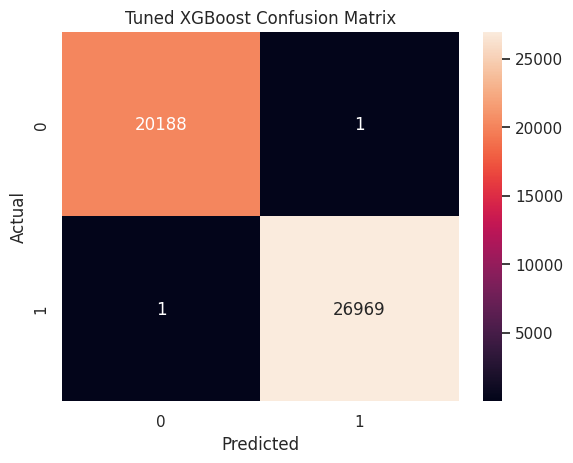

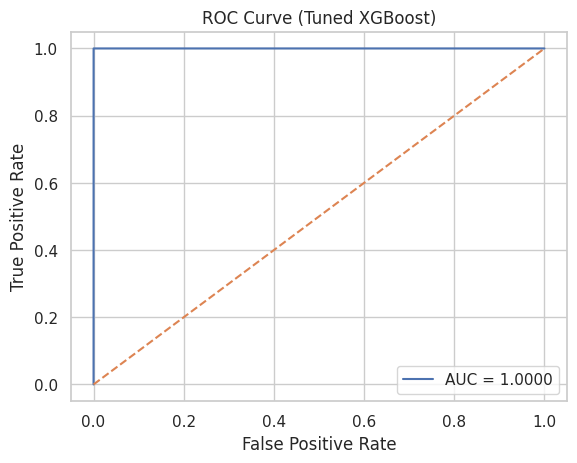

In [18]:
# EVALUATION: TUNED XGBOOST (FULL METRICS + VISUALS)

from sklearn.metrics import classification_report, roc_curve

print("\n--- Tuned XGBoost Performance ---")

# Core Metrics
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1-score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))


# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Tuned XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
roc_auc = roc_auc_score(y_test, y_prob_xgb)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Tuned XGBoost)")
plt.legend()
plt.show()

In [19]:
# COMPARATIVE ANALYSIS

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Helper: Evaluation Function
def evaluate_model(model, X_train, X_test, y_train, y_test, name):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }


# EXPERIMENT 1: MODEL COMPARISON

lr = LogisticRegression(max_iter=1000)
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

results_model = [
    evaluate_model(lr, X_train, X_test, y_train, y_test, "Logistic Regression"),
    evaluate_model(xgb, X_train, X_test, y_train, y_test, "XGBoost")
]

df_model = pd.DataFrame(results_model)

print("\n=== Experiment 1: Model Comparison ===")
display(df_model)


# EXPERIMENT 2: FEATURE SUBSET COMPARISON

# Define leakage-prone features
leakage_features = [
    'URLSimilarityIndex', 'TLDLegitimateProb', 'URLCharProb',
    'HasSocialNet', 'HasCopyrightInfo', 'HasDescription',
    'HasSubmitButton', 'IsResponsive',
    'DomainTitleMatchScore', 'URLTitleMatchScore'
]

# Remove them
X_no_leak = X.drop(columns=[col for col in leakage_features if col in X.columns])

# Scale
scaler = StandardScaler()
X_no_leak_scaled = scaler.fit_transform(X_no_leak)

# Split
X_train_nl, X_test_nl, y_train_nl, y_test_nl = train_test_split(
    X_no_leak_scaled, y, test_size=0.2, stratify=y, random_state=42
)

results_features = [
    evaluate_model(xgb, X_train, X_test, y_train, y_test, "Full Features"),
    evaluate_model(xgb, X_train_nl, X_test_nl, y_train_nl, y_test_nl, "No Leakage Features")
]

df_features = pd.DataFrame(results_features)

print("\n=== Experiment 2: Feature Subset Comparison ===")
display(df_features)


# EXPERIMENT 3: URL-ONLY FEATURES

url_strict_features = [
    'URLLength',
    'DomainLength',
    'NoOfSubDomain',
    'NoOfLettersInURL',
    'NoOfDegitsInURL',
    'NoOfEqualsInURL',
    'NoOfQMarkInURL',
    'NoOfAmpersandInURL',
    'NoOfOtherSpecialCharsInURL'
]

X_url = X[[col for col in url_strict_features if col in X.columns]]

# Scale
X_url_scaled = scaler.fit_transform(X_url)

# Split
X_train_url, X_test_url, y_train_url, y_test_url = train_test_split(
    X_url_scaled, y, test_size=0.2, stratify=y, random_state=42
)

results_url = [
    evaluate_model(xgb, X_train_url, X_test_url, y_train_url, y_test_url, "URL-Only Features")
]

df_url = pd.DataFrame(results_url)

print("\n=== Experiment 3: URL-Only Features ===")
display(df_url)


=== Experiment 1: Model Comparison ===


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.999661,0.999555,0.999852,0.999703,0.999997
1,XGBoost,0.999958,0.999963,0.999963,0.999963,0.999999



=== Experiment 2: Feature Subset Comparison ===


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Full Features,0.999958,0.999963,0.999963,0.999963,0.999999
1,No Leakage Features,0.999979,0.999963,1.000000,0.999981,0.999999



=== Experiment 3: URL-Only Features ===


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,URL-Only Features,0.995165,0.993759,0.997812,0.995782,0.998559



=== Experiment 4: LLM Explanation Evaluation ===


,Instance,Prediction,Confidence (%),Faithfulness,Explanation Length
0,0,Phishing,100.0,0.0,74
1,1,Phishing,100.0,0.0,83
2,2,Phishing,100.0,0.2,44
3,3,Phishing,100.0,0.2,43
4,4,Phishing,100.0,0.0,58



--- LLM Evaluation Summary ---
Average Faithfulness: 0.08
Average Explanation Length: 60.4
Average Confidence: 100.0


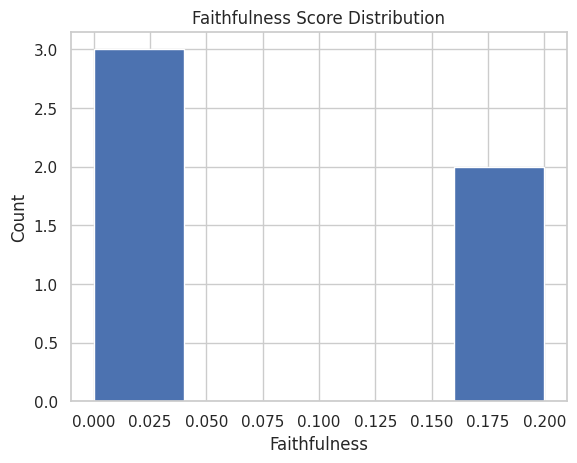

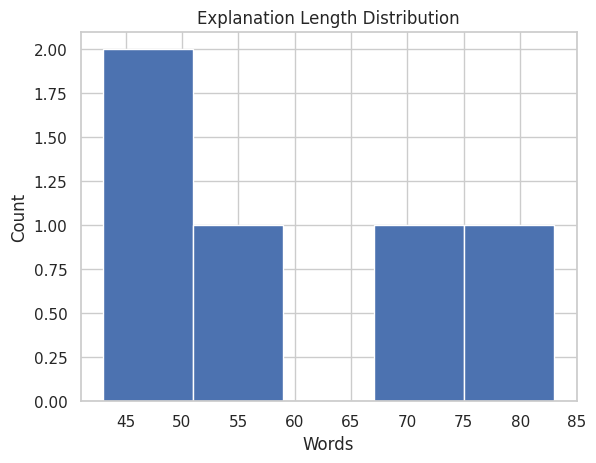

In [20]:
# EXPERIMENT 4: LLM EXPLANATION EVALUATION

import numpy as np

# Helper: Faithfulness Score
# Checks if key SHAP features are reflected in explanation text

def compute_faithfulness(explanation, top_features):

    explanation_lower = explanation.lower()
    matched = 0

    for _, row in top_features.iterrows():
        fname = row["feature"].lower()

        # Check either feature name OR semantic keyword
        if fname in explanation_lower:
            matched += 1

    return matched / len(top_features)


# Evaluate LLM Explanations
results_llm = []

for i in range(len(explanations_df)):

    explanation = explanations_df.iloc[i]["explanation"]

    # Recompute SHAP top features
    top_features = get_top_shap_features(
        shap_values_xgb,
        X_sample,
        index=i,
        top_k=5
    )

    # Faithfulness
    faithfulness = compute_faithfulness(explanation, top_features)

    # Length (proxy for cognitive load)
    length = len(explanation.split())

    # Confidence alignment
    confidence = float(explanations_df.iloc[i]["confidence"].replace("%", ""))

    results_llm.append({
        "Instance": i,
        "Prediction": explanations_df.iloc[i]["prediction"],
        "Confidence (%)": confidence,
        "Faithfulness": faithfulness,
        "Explanation Length": length
    })


df_llm_eval = pd.DataFrame(results_llm)

print("\n=== Experiment 4: LLM Explanation Evaluation ===")
display(df_llm_eval)


# Aggregate Metrics
print("\n--- LLM Evaluation Summary ---")

print("Average Faithfulness:", df_llm_eval["Faithfulness"].mean())
print("Average Explanation Length:", df_llm_eval["Explanation Length"].mean())
print("Average Confidence:", df_llm_eval["Confidence (%)"].mean())


# Visualisation
plt.figure()
plt.hist(df_llm_eval["Faithfulness"], bins=5)
plt.title("Faithfulness Score Distribution")
plt.xlabel("Faithfulness")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.hist(df_llm_eval["Explanation Length"], bins=5)
plt.title("Explanation Length Distribution")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()